# 03_Optimization_Scenarios.ipynb
**Goal:** Optimize battery charging/discharging schedules under uncertain renewable generation and demand.
**Key Techniques:**
- Linear Programming (`scipy.optimize.linprog`)
- Monte Carlo simulation for stochastic scenario generation
- Sensitivity plots for different capacity/cost assumptions

In [1]:
# %% [code]
import os
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pulp

pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8-whitegrid")

BASE_DIR = Path(".").resolve()
DATA_DIR = (BASE_DIR / ".." / "synthetic_energy_csvs").resolve()
MODELS_DIR = (BASE_DIR / ".." / "models").resolve()
OUTPUT_DIR = (BASE_DIR / ".." / "optimization_outputs").resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_DIR:", DATA_DIR)
print("MODELS_DIR:", MODELS_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

DATA_DIR: D:\synthetic_energy_csvs
MODELS_DIR: D:\models
OUTPUT_DIR: D:\optimization_outputs


In [2]:
# %% [code]
# Load region-level (daily) aggregates produced earlier (we expect ForecastDemandMWh/ForecastProductionMWh)
plants = pd.read_csv(DATA_DIR / "Plants.csv")
prod = pd.read_csv(DATA_DIR / "EnergyProduction.csv", parse_dates=["RecordDate"])
cons = pd.read_csv(DATA_DIR / "Consumption.csv", parse_dates=["RecordDate"])
forecast = pd.read_csv(DATA_DIR / "ForecastSnapshots.csv", parse_dates=["ForecastDate"])

# Build region_df (like earlier notebook)
cons_region = cons.groupby(["Region","RecordDate"], as_index=False)["EnergyConsumedMWh"].sum().rename(columns={"EnergyConsumedMWh":"ActualDemandMWh"})
# --- FIXED production-region aggregation ---
prod_merged = prod.merge(plants[["PlantID", "Region"]], on="PlantID", how="left")

# Prefer 'Region' from EnergyProduction if exists, else use from Plants
if "Region_x" in prod_merged.columns and "Region_y" in prod_merged.columns:
    prod_merged["Region"] = prod_merged["Region_x"].fillna(prod_merged["Region_y"])
elif "Region" not in prod_merged.columns:
    prod_merged["Region"] = "Unknown"

prod_region = (
    prod_merged
    .groupby(["Region", "RecordDate"], as_index=False)["EnergyGeneratedMWh"]
    .sum()
    .rename(columns={"EnergyGeneratedMWh": "ActualProductionMWh"})
)
forecast_r = forecast.rename(columns={"ForecastDate":"RecordDate","PredictedDemandMWh":"ForecastDemandMWh","PredictedProductionMWh":"ForecastProductionMWh"})
region_df = cons_region.merge(prod_region, on=["Region","RecordDate"], how="left").merge(forecast_r[["Region","RecordDate","ForecastDemandMWh","ForecastProductionMWh"]], on=["Region","RecordDate"], how="left")

# Conservative fill: forward/backward per region
region_df = region_df.sort_values(["Region","RecordDate"]).reset_index(drop=True)
region_df[['ActualDemandMWh','ActualProductionMWh','ForecastDemandMWh','ForecastProductionMWh']] = (
    region_df.groupby('Region')[['ActualDemandMWh','ActualProductionMWh','ForecastDemandMWh','ForecastProductionMWh']]
             .transform(lambda g: g.ffill().bfill())
)

# Select example region and window (last N days)
REGION = "Central"   # change freely
WINDOW_DAYS = 30
r_df = region_df[region_df.Region==REGION].sort_values("RecordDate").reset_index(drop=True)
if len(r_df) < WINDOW_DAYS:
    raise RuntimeError(f"Not enough rows ({len(r_df)}) for region {REGION}. Decrease WINDOW_DAYS.")
window = r_df.tail(WINDOW_DAYS).copy().reset_index(drop=True)

# For optimization we will use forecast columns if present, else fall back to actuals
window["Demand"] = window["ForecastDemandMWh"].fillna(window["ActualDemandMWh"])
window["Production"] = window["ForecastProductionMWh"].fillna(window["ActualProductionMWh"])

print("Window shape:", window.shape)
window.head()

Window shape: (30, 8)


,Region,RecordDate,ActualDemandMWh,ActualProductionMWh,ForecastDemandMWh,ForecastProductionMWh,Demand,Production
0,Central,2024-12-02,6087.999,1910.163,6094.169136,1879.294083,6094.169136,1879.294083
1,Central,2024-12-03,5468.838,1567.928,4954.245005,1535.985466,4954.245005,1535.985466
2,Central,2024-12-04,5468.759,2001.860,5857.987871,1983.067731,5857.987871,1983.067731
3,Central,2024-12-05,6878.952,1639.048,7750.467016,1687.511931,7750.467016,1687.511931
4,Central,2024-12-06,5567.441,2041.949,5269.066881,2077.587788,5269.066881,2077.587788


In [3]:
# %% [code]
# Quick toy test: 3 timesteps, simple battery params
toy_demand = np.array([100., 150., 120.])
toy_prod   = np.array([80., 140., 200.])
battery_params = {
    "capacity_mwh": 100.0,
    "max_charge_mw": 50.0,
    "max_discharge_mw": 50.0,
    "soc_init_mwh": 50.0,
    "soc_min_mwh": 10.0,
    "soc_max_mwh": 90.0,
    "charge_eff": 0.95,
    "discharge_eff": 0.95
}

import numpy as np
import pulp

def lp_battery_dispatch(demand, production, battery_params, cost_import=100):
    """
    demand, production: numpy arrays (MWh)
    battery_params: dict with keys
        - cap (MWh)
        - charge_rate (MW)
        - discharge_rate (MW)
        - eff_charge (0-1)
        - eff_discharge (0-1)
    """
    n = len(demand)
    cap = battery_params["cap"]
    cr = battery_params["charge_rate"]
    dr = battery_params["discharge_rate"]
    eff_c = battery_params["eff_charge"]
    eff_d = battery_params["eff_discharge"]

    prob = pulp.LpProblem("BatteryDispatch", pulp.LpMinimize)

    # Decision variables
    charge = pulp.LpVariable.dicts("charge", range(n), lowBound=0, upBound=cr)
    discharge = pulp.LpVariable.dicts("discharge", range(n), lowBound=0, upBound=dr)
    import_grid = pulp.LpVariable.dicts("import", range(n), lowBound=0)
    soc = pulp.LpVariable.dicts("soc", range(n), lowBound=0, upBound=cap)

    # Objective: minimize grid imports (proxy for cost)
    prob += pulp.lpSum(import_grid[t] * cost_import for t in range(n))

    # Constraints
    for t in range(n):
        # Energy balance: demand met by prod + discharge + import - charge
        prob += production[t] + discharge[t] + import_grid[t] >= demand[t] + charge[t]

    for t in range(n):
        if t == 0:
            prob += soc[t] == cap * 0.5 + (charge[t]*eff_c - discharge[t]/eff_d)
        else:
            prob += soc[t] == soc[t-1] + (charge[t]*eff_c - discharge[t]/eff_d)

        # Keep SOC in [0, cap]
        prob += soc[t] <= cap
        prob += soc[t] >= 0

    # Mild relaxation: allow import if needed to stay feasible
    prob.solve(pulp.PULP_CBC_CMD(msg=False))

    if pulp.LpStatus[prob.status] != "Optimal":
        print("⚠️ LP infeasible or unbounded. Status:", pulp.LpStatus[prob.status])
        # Debug: print a few variable values if available
        for v in prob.variables()[:5]:
            print(v.name, v.varValue)
        return None

    # Collect results
    res = {
        "charge": np.array([v.value() for v in charge.values()]),
        "discharge": np.array([v.value() for v in discharge.values()]),
        "import": np.array([v.value() for v in import_grid.values()]),
        "soc": np.array([v.value() for v in soc.values()])
    }
    return res

In [4]:
# %% [code]
def optimize_with_pulp(demand, production, battery_params, cost_import=1000.0):
    """
    Robust LP using PuLP.
    demand, production: numpy arrays length T
    battery_params: dict with keys as in toy example (use mwh units)
    Returns: dict with arrays charge, discharge, import, soc
    """
    # basic checks
    assert len(demand) == len(production), "demand and production length mismatch"
    T = len(demand)
    # Build problem
    prob = pulp.LpProblem("battery_dispatch", pulp.LpMinimize)
    # Variables
    charge = [pulp.LpVariable(f"charge_{t}", lowBound=0, upBound=battery_params["max_charge_mw"]) for t in range(T)]
    discharge = [pulp.LpVariable(f"discharge_{t}", lowBound=0, upBound=battery_params["max_discharge_mw"]) for t in range(T)]
    import_grid = [pulp.LpVariable(f"import_{t}", lowBound=0) for t in range(T)]
    soc = [pulp.LpVariable(f"soc_{t}", lowBound=battery_params["soc_min_mwh"], upBound=battery_params["soc_max_mwh"]) for t in range(T)]
    # Objective: prioritize unmet avoidance via grid cost; you can adjust cost_import small/large
    prob += pulp.lpSum([cost_import * import_grid[t] for t in range(T)])
    # Constraints
    for t in range(T):
        prob += production[t] + discharge[t] * battery_params["discharge_eff"] + import_grid[t] == demand[t] + charge[t] / battery_params["charge_eff"]
        if t == 0:
            prob += soc[t] == battery_params["soc_init_mwh"] + charge[t]*battery_params["charge_eff"] - discharge[t]/battery_params["discharge_eff"]
        else:
            prob += soc[t] == soc[t-1] + charge[t]*battery_params["charge_eff"] - discharge[t]/battery_params["discharge_eff"]
    # Solve quietly
    prob.solve(pulp.PULP_CBC_CMD(msg=False))
    status = pulp.LpStatus[prob.status]
    if status != "Optimal":
        raise RuntimeError("Optimization failed with status: " + status)
    return {
        "charge": np.array([v.value() for v in charge], dtype=float),
        "discharge": np.array([v.value() for v in discharge], dtype=float),
        "import": np.array([v.value() for v in import_grid], dtype=float),
        "soc": np.array([v.value() for v in soc], dtype=float)
    }


In [5]:
# %% [code]
# Example battery params (daily-step MWh units)
battery_params = {
    "capacity_mwh": 200.0,
    "max_charge_mw": 50.0,
    "max_discharge_mw": 50.0,
    "soc_init_mwh": 100.0,
    "soc_min_mwh": 20.0,
    "soc_max_mwh": 180.0,
    "charge_eff": 0.95,
    "discharge_eff": 0.95
}

demand = window["Demand"].values.astype(float)
production = window["Production"].values.astype(float)

scenarios = {
    "Base": (1.0, 1.0),
    "HighDemand": (1.10, 1.0),
    "LowRenewables": (1.0, 0.80),
    "RenewableBoost": (1.0, 1.10)
}

scenario_results = {}
for name, (d_mult, p_mult) in scenarios.items():
    d = demand * d_mult
    p = production * p_mult
    out = optimize_with_pulp(d, p, battery_params, cost_import=1000.0)
    total_import = out["import"].sum()
    scenario_results[name] = {"out": out, "total_import": float(total_import)}
    print(f"{name}: total grid import = {total_import:.2f} MWh")


Base: total grid import = 113521.49 MWh
HighDemand: total grid import = 131055.33 MWh
LowRenewables: total grid import = 125870.43 MWh
RenewableBoost: total grid import = 107347.02 MWh


In [6]:
# %% [code]
# Monte Carlo: perturb demand and production multiplicatively
n_runs = 200
mc_rows = []
rng = np.random.default_rng(42)

for i in range(n_runs):
    d_mult = rng.normal(1.0, 0.05)   # 5% demand volatility
    p_mult = rng.normal(1.0, 0.08)   # 8% production volatility
    d = demand * d_mult
    p = production * p_mult
    try:
        out = optimize_with_pulp(d, p, battery_params, cost_import=1000.0)
        mc_rows.append({
            "run": i,
            "total_import": float(out["import"].sum()),
            "total_charge": float(out["charge"].sum()),
            "total_discharge": float(out["discharge"].sum()),
            "avg_soc": float(np.mean(out["soc"]))
        })
    except Exception as e:
        mc_rows.append({"run": i, "error": str(e)})

mc_df = pd.DataFrame(mc_rows)
mc_df.describe()


,run,total_import,total_charge,total_discharge,avg_soc
count,200.000000,200.000000,200.0,200.0,200.000000
mean,99.500000,113874.876426,0.0,76.0,20.912281
std,57.879185,9532.635940,0.0,0.0,0.000000
min,0.000000,91930.500700,0.0,76.0,20.912281
25%,49.750000,106878.178775,0.0,76.0,20.912281
50%,99.500000,112843.583150,0.0,76.0,20.912281
75%,149.250000,120107.433775,0.0,76.0,20.912281
max,199.000000,144777.020900,0.0,76.0,20.912281


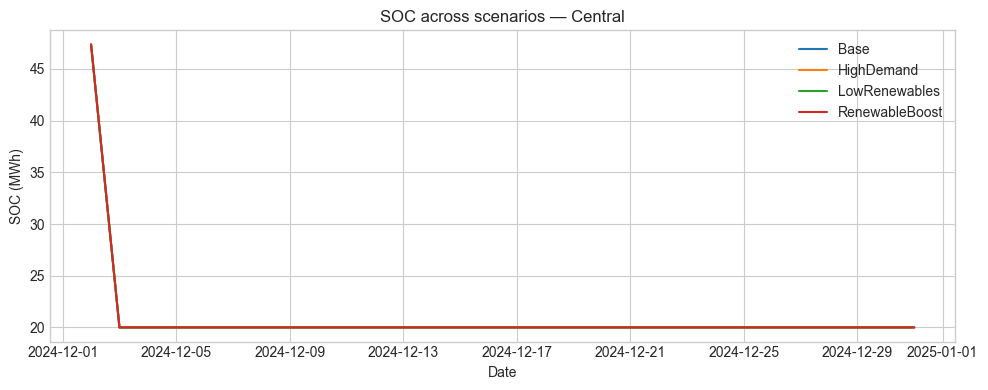

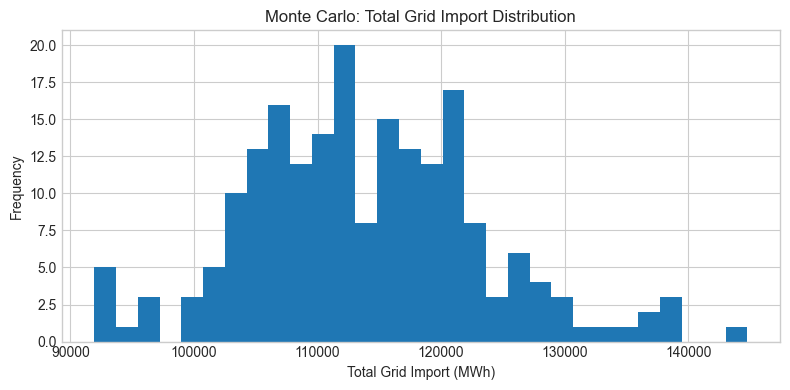

Saved scenario dispatch outputs to D:\optimization_outputs
Saved Monte Carlo results to D:\optimization_outputs


In [8]:
# %% [code]
# Plot scenario SOC
plt.figure(figsize=(10,4))
for name, info in scenario_results.items():
    soc = info["out"]["soc"]
    plt.plot(window["RecordDate"], soc, label=name)
plt.title(f"SOC across scenarios — {REGION}")
plt.xlabel("Date"); plt.ylabel("SOC (MWh)"); plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# Histogram of Monte Carlo total imports
plt.figure(figsize=(8,4))
plt.hist(mc_df["total_import"].dropna(), bins=30)
plt.title("Monte Carlo: Total Grid Import Distribution")
plt.xlabel("Total Grid Import (MWh)"); plt.ylabel("Frequency"); plt.grid(True); plt.tight_layout(); plt.show()

# Save CSVs
for name, info in scenario_results.items():
    df_out = pd.DataFrame({
        "RecordDate": window["RecordDate"],
        "charge": info["out"]["charge"],
        "discharge": info["out"]["discharge"],
        "soc": info["out"]["soc"],
        "import": info["out"]["import"]
    })
    path = OUTPUT_DIR / f"dispatch_{REGION}_{name}.csv"
    df_out.to_csv(path, index=False)
print("Saved scenario dispatch outputs to", OUTPUT_DIR)

mc_df.to_csv(OUTPUT_DIR / f"mc_results_{REGION}.csv", index=False)
print("Saved Monte Carlo results to", OUTPUT_DIR)